Лабораторна робота No3. Дерева прийняття рішень 

In [1]:
import pandas as pd
df = pd.read_csv("ЛР3-пгр2.csv", sep=";")
df.shape


(1599, 12)

In [2]:
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


In [3]:
from sklearn.model_selection import train_test_split

X = df.drop("quality", axis=1)
y = df["quality"]

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42)

print("Розмір тренувальної вибірки:", X_train.shape)
print("Розмір тестової вибірки:", X_test.shape)


Розмір тренувальної вибірки: (1279, 11)
Розмір тестової вибірки: (320, 11)


In [4]:
from sklearn.tree import DecisionTreeClassifier


# Створюємо модель дерева рішень з глибиною 5
clf = DecisionTreeClassifier(max_depth=5, random_state=42, criterion='entropy')

# Навчаємо модель на тренувальній вибірці
clf.fit(X_train, y_train)

# Оцінка точності на тестовій вибірці
#accuracy = clf.score(X_test, y_test)
#accuracy



DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

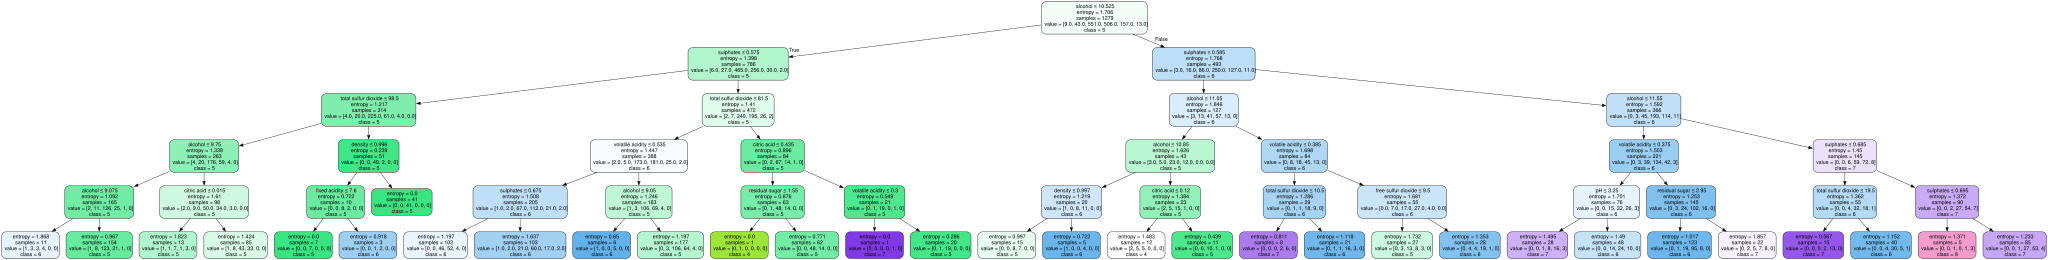

In [5]:
from sklearn.tree import export_graphviz
import graphviz


dot_data = export_graphviz(
    clf,
    out_file=None, 
    feature_names=X.columns,   # назви ознак
    class_names=[str(i) for i in sorted(y.unique())],  # назви класів
    filled=True, rounded=True,
    special_characters=True
)


graph = graphviz.Source(dot_data)

graph



Тренувальна вибірка:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.46      0.14      0.21        43
           5       0.69      0.77      0.73       551
           6       0.63      0.61      0.62       506
           7       0.61      0.62      0.61       157
           8       0.60      0.23      0.33        13

    accuracy                           0.66      1279
   macro avg       0.50      0.40      0.42      1279
weighted avg       0.65      0.66      0.65      1279

Тестова вибірка:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        10
           5       0.63      0.72      0.67       130
           6       0.57      0.55      0.56       132
           7       0.48      0.48      0.48        42
           8       0.00      0.00      0.00         5

    accuracy                           

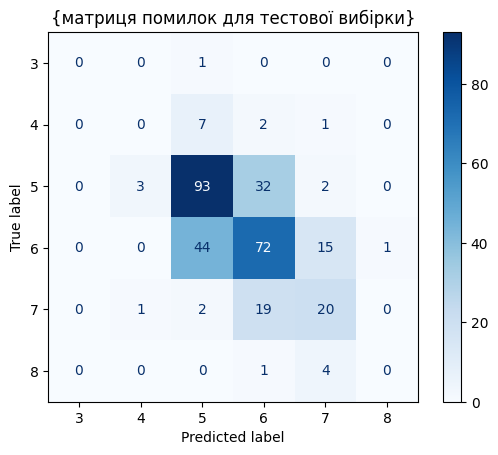

In [6]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.exceptions import UndefinedMetricWarning
import warnings


warnings.filterwarnings("ignore", category=UndefinedMetricWarning)
    
    # Тренувальна вибірка
y_train_pred = clf.predict(X_train)
print("Тренувальна вибірка:")
print(classification_report(y_train, y_train_pred))
    
    # Тестова вибірка
y_test_pred = clf.predict(X_test)
print("Тестова вибірка:")
print(classification_report(y_test, y_test_pred))
    
# Побудова матриці помилок для тестової вибірки
disp = ConfusionMatrixDisplay.from_estimator( clf, X_test, y_test, cmap='Blues', values_format='d')
plt.title("{матриця помилок для тестової вибірки}")
plt.show()




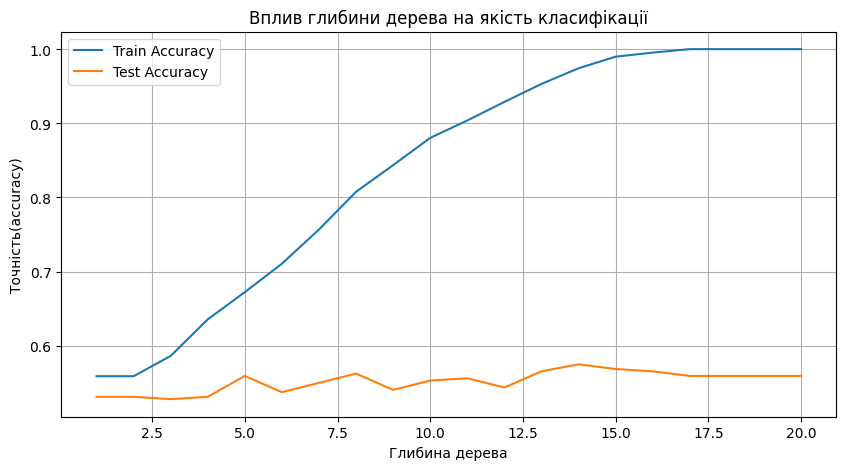

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score


depths = np.arange(1, 21) 
train_acc = []
test_acc = []

for d in depths:
    # Створюємо нову модель на кожній глибині
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    train_acc.append(accuracy_score(y_train, y_train_pred))
    test_acc.append(accuracy_score(y_test, y_test_pred))

plt.figure(figsize=(10, 5))
plt.plot(depths, train_acc, label="Train Accuracy")
plt.plot(depths, test_acc, label="Test Accuracy")
plt.xlabel("Глибина дерева")
plt.ylabel("Точність(аccuracy)")
plt.title("Вплив глибини дерева на якість класифікації")
plt.legend()
plt.grid()
plt.show()

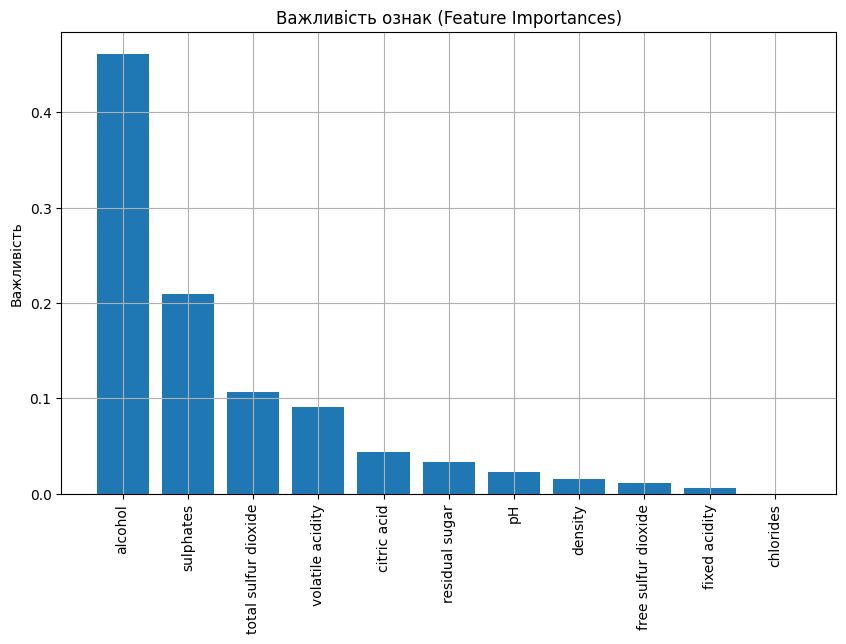

In [8]:


# Отримуємо важливості ознак
importances = clf.feature_importances_

# Сортуємо за важливістю
indices = np.argsort(importances)[::-1]

# Будуємо графік
plt.figure(figsize=(10, 6))
plt.title("Важливість ознак (Feature Importances)")
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), X.columns[indices], rotation=90)
plt.ylabel("Важливість")
plt.grid()
plt.show()